In [1]:
import os
import glob
import torch
from PIL import Image
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd()))
from inference import load_model, get_transform
from utils import tensor_to_image


In [2]:
def transform_with_all_models(image, checkpoint_dir="./checkpoints"):
    """
    Transform an image to Van Gogh style using all checkpoint models.
    
    Args:
        image: Image path (str) or PIL Image
        checkpoint_dir: Directory with checkpoints (default: "./checkpoints")
    
    Returns:
        Dictionary of {checkpoint_name: transformed_image}
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load image
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')
    original_size = image.size
    
    # Find all checkpoints
    checkpoints = sorted(glob.glob(os.path.join(checkpoint_dir, "checkpoint_epoch_*.pth")))
    print(f"Found {len(checkpoints)} checkpoints")
    
    # Prepare image
    transform = get_transform(256)
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    results = {}
    for ckpt_path in checkpoints:
        ckpt_name = os.path.basename(ckpt_path)
        try:
            # Load model and transform
            generator = load_model(ckpt_path, device)
            with torch.no_grad():
                styled = generator(img_tensor)
            
            # Convert to PIL
            styled_array = tensor_to_image(styled)
            styled_img = Image.fromarray((styled_array * 255).astype('uint8'))
            if styled_img.size != original_size:
                styled_img = styled_img.resize(original_size, Image.LANCZOS)
            
            results[ckpt_name] = styled_img
            print(f"✓ {ckpt_name}")
        except Exception as e:
            print(f"✗ {ckpt_name}: {e}")
    
    return results


In [3]:
results = transform_with_all_models("./dataset/vangogh2photo/testB/2014-08-01 22:38:22.jpg")

Found 20 checkpoints
✓ checkpoint_epoch_10.pth
✓ checkpoint_epoch_100.pth
✓ checkpoint_epoch_15.pth
✓ checkpoint_epoch_20.pth
✓ checkpoint_epoch_25.pth
✓ checkpoint_epoch_30.pth
✓ checkpoint_epoch_35.pth
✓ checkpoint_epoch_40.pth
✓ checkpoint_epoch_45.pth
✓ checkpoint_epoch_5.pth
✓ checkpoint_epoch_50.pth
✓ checkpoint_epoch_55.pth
✓ checkpoint_epoch_60.pth
✓ checkpoint_epoch_65.pth
✓ checkpoint_epoch_70.pth
✓ checkpoint_epoch_75.pth
✓ checkpoint_epoch_80.pth
✓ checkpoint_epoch_85.pth
✓ checkpoint_epoch_90.pth
✓ checkpoint_epoch_95.pth


In [4]:
results

{'checkpoint_epoch_10.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_100.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_15.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_20.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_25.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_30.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_35.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_40.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_45.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_5.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_50.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_55.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_60.pth': <PIL.Image.Image image mode=RGB size=256x256>,
 'checkpoint_epoch_65.pth

In [ ]:
# Example:
# results = transform_with_all_models("path/to/image.jpg")
# results['checkpoint_epoch_100.pth'].save("output.jpg")


IndexError: index 5 is out of bounds for axis 0 with size 5

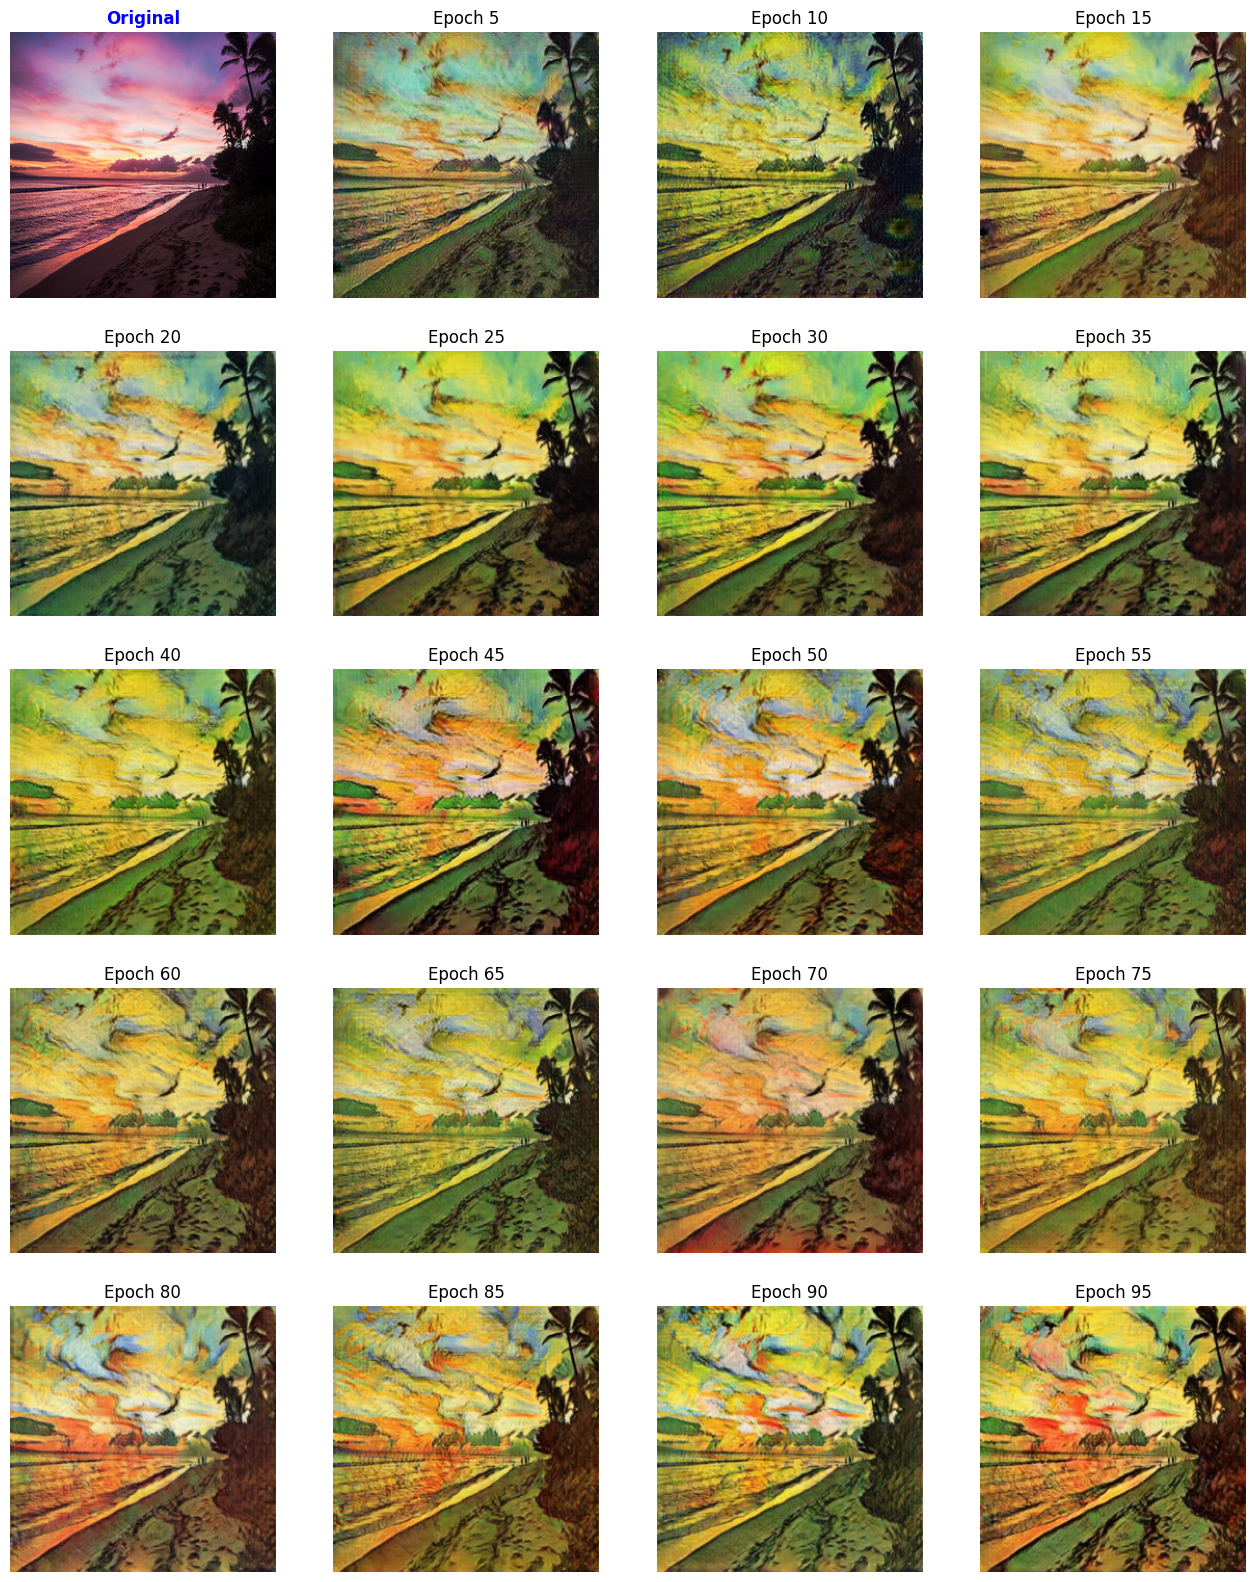

In [9]:
import matplotlib.pyplot as plt

# Assuming you have the original image
original = Image.open("./dataset/vangogh2photo/testB/2014-08-01 22:38:22.jpg")  # or use the image you passed to transform_with_all_models

sorted_results = sorted(results.items(), key=lambda x: int(x[0].replace('checkpoint_epoch_', '').replace('.pth', '')))

# Create grid with original + results
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

# Original
axes[0, 0].imshow(original)
axes[0, 0].set_title("Original", fontweight='bold', color='blue')
axes[0, 0].axis('off')

# Results in epoch order
for idx, (name, img) in enumerate(sorted_results):
    row = (idx + 1) // 4
    col = (idx + 1) % 4
    axes[row, col].imshow(img)
    epoch = name.replace('checkpoint_epoch_', '').replace('.pth', '')
    axes[row, col].set_title(f"Epoch {epoch}")
    axes[row, col].axis('off')

# Hide unused
for idx in range(len(results) + 1, 20):
    row, col = idx // 4, idx % 4
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [2]:
generator = load_model("./checkpoints/checkpoint_epoch_100.pth")
print(generator)

Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): C

In [9]:
checkpoint = torch.load("./checkpoints/checkpoint_epoch_100.pth", map_location='cpu', weights_only=False)
print(checkpoint.keys())

dict_keys(['epoch', 'G_AB', 'G_BA', 'D_A', 'D_B', 'optimizer_G', 'optimizer_D_A', 'optimizer_D_B', 'config'])


In [10]:
checkpoint['epoch']

99